# 📓 Linear Regression from Scratch

### 🎯 Objective
- Implement a linear regression model using gradient descent. 
- Derive the gradient updates, write a scikit-learn-like class, and evaluate using synthetic data.
- Compare the result of the same with library code output
- Use R2-Score and Mean Absolute Percentage error as Performance metric on test data

## 📊 Generate Synthetic Data

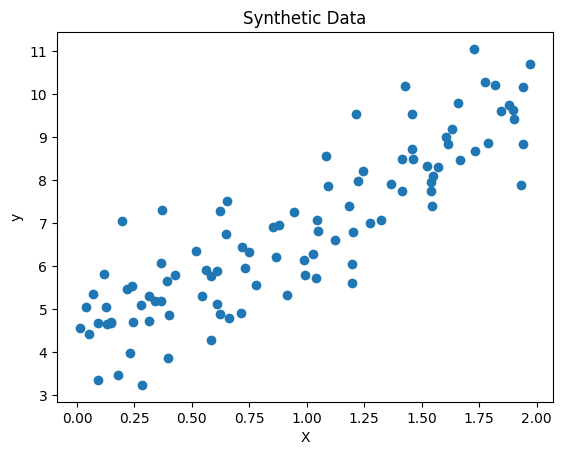

In [1]:

import numpy as np
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(42)

# Generate synthetic data
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# Plot
plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Synthetic Data")
plt.show()


## Do Train-Test Split (75%-25%)

In [2]:
# Write your code here
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (75, 1)
y_train shape: (75, 1)
X_test shape: (25, 1)
y_test shape: (25, 1)


## Do the Linear Regression with Scikit-Learn Library

In [3]:
# Write your code here
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_percentage_error

model_sklearn = LinearRegression()
model_sklearn.fit(X_train, y_train)
y_pred_sklearn = model_sklearn.predict(X_test)
r2 = r2_score(y_test, y_pred_sklearn)
mape = mean_absolute_percentage_error(y_test, y_pred_sklearn) * 100

print(f"Scikit-Learn Linear Regression R2 Score: {r2:.4f}")
print(f"Scikit-Learn Linear Regression MAPE: {mape:.2f}%")
print(f"Learned coefficients (m): {model_sklearn.coef_[0][0]:.4f}")
print(f"Learned intercept (c): {model_sklearn.intercept_[0]:.4f}")

Scikit-Learn Linear Regression R2 Score: 0.8311
Scikit-Learn Linear Regression MAPE: 8.48%
Learned coefficients (m): 2.7259
Learned intercept (c): 4.1688


## Do Ridge and Lasso Regression and Compare the evaluation metrics in a table

In [4]:
import pandas as pd
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_percentage_error

model_ridge = Ridge()
model_ridge.fit(X_train, y_train)
y_pred_ridge = model_ridge.predict(X_test)
r2_ridge = r2_score(y_test, y_pred_ridge)
mape_ridge = mean_absolute_percentage_error(y_test, y_pred_ridge) * 100

print(f"Ridge Regression R2 Score: {r2_ridge:.4f}")
print(f"Ridge Regression MAPE: {mape_ridge:.2f}%\n")


model_lasso = Lasso()
model_lasso.fit(X_train, y_train)
y_pred_lasso = model_lasso.predict(X_test)
r2_lasso = r2_score(y_test, y_pred_lasso)
mape_lasso = mean_absolute_percentage_error(y_test, y_pred_lasso) * 100

print(f"Lasso Regression R2 Score: {r2_lasso:.4f}")
print(f"Lasso Regression MAPE: {mape_lasso:.2f}%\n")

results = {
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'R2 Score': [r2, r2_ridge, r2_lasso],
    'MAPE (%)': [mape, mape_ridge, mape_lasso]
}

df_results = pd.DataFrame(results)
display(df_results.style.format({
    'R2 Score': '{:.4f}',
    'MAPE (%)': '{:.2f}'
}))

Ridge Regression R2 Score: 0.8260
Ridge Regression MAPE: 8.24%

Lasso Regression R2 Score: -0.0853
Lasso Regression MAPE: 24.24%



,Model,R2 Score,MAPE (%)
0,Linear Regression,0.8311,8.48
1,Ridge Regression,0.8260,8.24
2,Lasso Regression,-0.0853,24.24


## Custom Implementation

## 🧮 Derive the Gradient Updates
Use the chain rule to derive the gradients of the loss function (Mean Square Error):

$$ \text{Loss} = \frac{1}{N} \sum_{i=1}^{N} (y_i - (mx_i + c))^2 $$

Derive:
- ∂Loss/∂m
- ∂Loss/∂c

Write the derivation here/add screenshot of your derivation here:
### Mean Squared Error Loss

Loss:

$$
\text{Loss} = \frac{1}{N} \sum_{i=1}^{N} (y_i - (mx_i + c))^2
$$

---

### Define prediction

$$
\hat{y}_i = mx_i + c
$$

$$
e_i = y_i - \hat{y}_i
$$

$$
\text{Loss} = \frac{1}{N}\sum_{i=1}^{N} e_i^2
$$

---

# Gradient w.r.t m

Chain rule:

$$
\frac{\partial \text{Loss}}{\partial m}
=
\frac{1}{N}\sum_{i=1}^{N}
\frac{\partial (e_i^2)}{\partial m}
$$

$$
\frac{\partial (e_i^2)}{\partial m}
=
2 e_i \cdot \frac{\partial e_i}{\partial m}
$$

Since

$$
e_i = y_i - (mx_i + c)
$$

$$
\frac{\partial e_i}{\partial m} = -x_i
$$

Therefore

$$
\frac{\partial \text{Loss}}{\partial m}
=
-\frac{2}{N}\sum_{i=1}^{N}
x_i (y_i - (mx_i + c))
$$

---

# Gradient w.r.t c

$$
\frac{\partial \text{Loss}}{\partial c}
=
\frac{1}{N}\sum_{i=1}^{N}
\frac{\partial (e_i^2)}{\partial c}
$$

$$
\frac{\partial (e_i^2)}{\partial c}
=
2 e_i \cdot (-1)
$$

Therefore

$$
\frac{\partial \text{Loss}}{\partial c}
=
-\frac{2}{N}\sum_{i=1}^{N}
(y_i - (mx_i + c))
$$


## 🧠 Custom Linear Regression Class

In [19]:
class MyLinearRegression:
    def __init__(self):
        self.m = None
        self.c = None
        self.loss_history = []

    def fit(self, X, y, lr=0.01, n_iters=1000):
        # Initialize parameters
        # Reshape X to (n_samples, n_features) if it's a 1D array
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        
        # Initialize m and c randomly
        self.m = np.random.randn(X.shape[1], 1)
        self.c = np.random.randn(1, 1)

        N = len(X)

        for _ in range(n_iters):
            # Predictions
            y_pred = X @ self.m + self.c

            # Calculate loss (Mean Squared Error)
            loss = (1/N) * np.sum((y - y_pred)**2)
            self.loss_history.append(loss)

            # Gradients
            dm = (-2/N) * (X.T @ (y - y_pred))
            dc = (-2/N) * np.sum(y - y_pred)

            
            self.m -= lr * dm
            self.c -= lr * dc

    def predict(self, X):
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        if self.m is None or self.c is None:
            raise Exception("Model has not been trained yet. Call fit() first.")
        return X @ self.m + self.c

    def fit_transform(self, X, y, lr=0.01, n_iters=1000):
        self.fit(X, y, lr, n_iters)
        return self.predict(X)

    @property
    def coef_(self):
        return self.m

    @property
    def intercept_(self):
        return self.c


## 🔁 Train the Model and Visualize the Fit

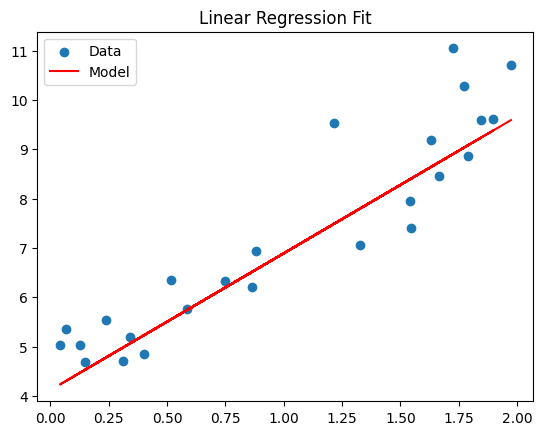

Learned coefficients (m, c): [[2.77421326]] [[4.1161842]]


In [20]:

model = MyLinearRegression()
model.fit(X_train, y_train, lr=0.1, n_iters=100)


y_pred = model.predict(X_test)

plt.scatter(X_test, y_test, label="Data")
plt.plot(X_test, y_pred, color="red", label="Model")
plt.legend()
plt.title("Linear Regression Fit")
plt.show()

print("Learned coefficients (m, c):", model.coef_,model.intercept_)


## 📉 Plot the Loss Curve

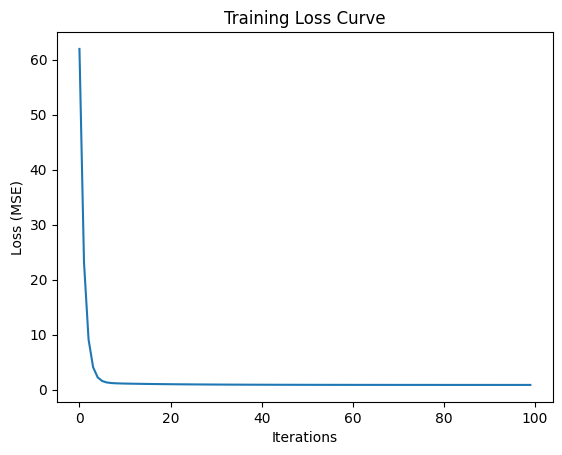

In [21]:
# Write your code here
plt.plot(model.loss_history)
plt.xlabel("Iterations")
plt.ylabel("Loss (MSE)")
plt.title("Training Loss Curve")
plt.show()

## 🌟 Bonus Task: Stochastic Gradient Descent
Implement a class `MyLinearRegressionSGD` that uses one training sample per iteration to update weights.

In [22]:
# Write your code here
class MyLinearRegressionSGD(MyLinearRegression):
    def fit(self, X, y, lr=0.01, n_iters=1000):
        # Initialize parameters
        if X.ndim == 1:
            X = X.reshape(-1, 1)

        self.m = np.random.randn(X.shape[1], 1)
        self.c = np.random.randn(1, 1)

        N = len(X)
        self.loss_history = []

        for _ in range(n_iters):
            # Select a random sample for SGD
            random_index = np.random.randint(N)
            X_sample = X[random_index].reshape(1, -1)
            y_sample = y[random_index].reshape(1, -1)

            # Prediction for the single sample
            y_pred_sample = X_sample @ self.m + self.c

            # Gradients for the single sample
            dm = -2 * (X_sample.T @ (y_sample - y_pred_sample))
            dc = -2 * np.sum(y_sample - y_pred_sample)

            # Update parameters
            self.m -= lr * dm
            self.c -= lr * dc

            # Calculate and store loss over the entire dataset (for monitoring)
            y_pred_full = X @ self.m + self.c
            loss = (1/N) * np.sum((y - y_pred_full)**2)
            self.loss_history.append(loss)

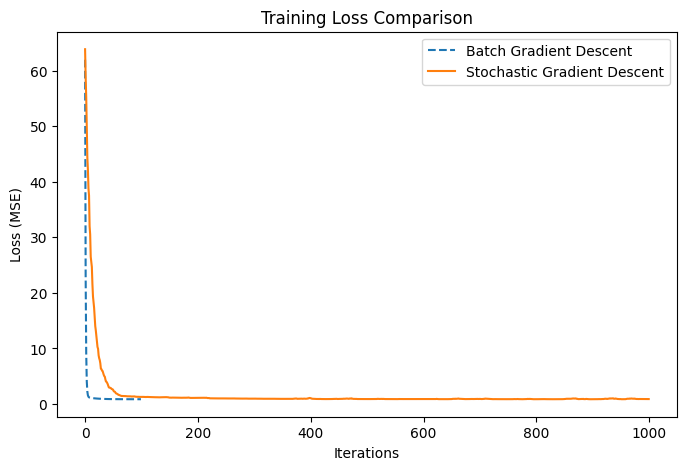

In [23]:
# Plot loss curve while using Stochastic Gradient Descent
plt.figure(figsize=(8,5))

plt.plot(model.loss_history, linestyle='--', label="Batch Gradient Descent")
plt.plot(model_sgd.loss_history, label="Stochastic Gradient Descent")

plt.xlabel("Iterations")
plt.ylabel("Loss (MSE)")
plt.title("Training Loss Comparison")
plt.legend()

plt.show()

## Visualize the prediction result of Library version and Custom regression code created

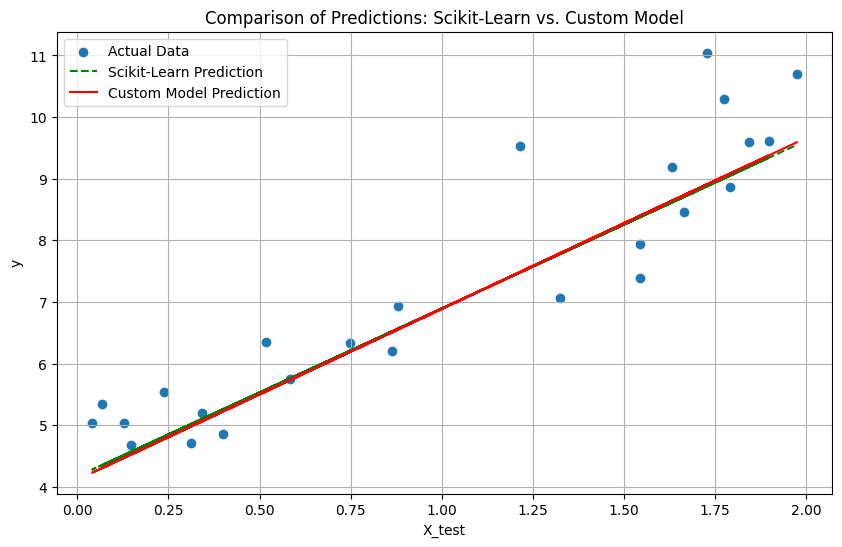

In [24]:
# Write your code here
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, label="Actual Data")
plt.plot(X_test, y_pred_sklearn, color="green", linestyle='--', label="Scikit-Learn Prediction")
plt.plot(X_test, y_pred, color="red", label="Custom Model Prediction")
plt.xlabel("X_test")
plt.ylabel("y")
plt.title("Comparison of Predictions: Scikit-Learn vs. Custom Model")
plt.legend()
plt.grid(True)
plt.show()

## ✅ Checklist
- [✅] Did linear regression using scikit-learn API
- [✅] Did Ridge and Lasso regression and compiled the result (R2 and MAPE) as a table
- [✅] Derived gradients using chain rule
- [✅] Implemented custom Linear Regression class
- [✅] Trained using gradient descent
- [✅] Visualized predictions and loss
- [✅] Implemented stochastic gradient descent (bonus)
- [✅] Visualized predictions and loss for stochastic gradient descent (bonus)
- [✅] Visualize the prediction result of Library version and custom version